# Step 1: The Dataset

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Number of simulated interns
n = 500

# Create dataset
data = pd.DataFrame({
    "Week1_Python_EDA_Score": np.random.randint(50, 101, n),
    "Week2_Data_Preprocessing_Score": np.random.randint(50, 101, n),
    "Week3_Classification_Model_Score": np.random.randint(50, 101, n),
    "Week4_Regression_Model_Score": np.random.randint(50, 101, n),
    "Week5_Clustering_Score": np.random.randint(50, 101, n),
    "Week6_NLP_Score": np.random.randint(50, 101, n),
    "Week7_Model_Deployment_Score": np.random.randint(50, 101, n),
    "Week8_Final_Capstone_Project_Score": np.random.randint(50, 101, n),

    "Tasks_Delivered": np.random.randint(5, 9, n),
    "OnTime_Submissions": np.random.randint(4, 9, n)
})

# Calculate late submissions
data["Late_Submissions"] = 8 - data["OnTime_Submissions"]

# List of all 8 internship tasks
task_columns = [
    "Week1_Python_EDA_Score",
    "Week2_Data_Preprocessing_Score",
    "Week3_Classification_Model_Score",
    "Week4_Regression_Model_Score",
    "Week5_Clustering_Score",
    "Week6_NLP_Score",
    "Week7_Model_Deployment_Score",
    "Week8_Final_Capstone_Project_Score"
]

# Calculate average task score
average_task_score = data[task_columns].mean(axis=1)

# Create overall score
data["Overall_Score"] = (
    average_task_score * 0.80
    + (data["Tasks_Delivered"] / 8 * 100) * 0.10
    + (data["OnTime_Submissions"] / 8 * 100) * 0.10
)

# Add small realistic variation
data["Overall_Score"] += np.random.normal(0, 2, n)

# Keep score between 0 and 100
data["Overall_Score"] = data["Overall_Score"].clip(0, 100).round(2)

print("Dataset created successfully!")
print("Dataset Shape:", data.shape)

data.head()

Dataset created successfully!
Dataset Shape: (500, 12)


,Week1_Python_EDA_Score,Week2_Data_Preprocessing_Score,Week3_Classification_Model_Score,Week4_Regression_Model_Score,Week5_Clustering_Score,Week6_NLP_Score,Week7_Model_Deployment_Score,Week8_Final_Capstone_Project_Score,Tasks_Delivered,OnTime_Submissions,Late_Submissions,Overall_Score
0,88,77,90,95,74,70,57,72,8,5,3,76.24
1,78,54,94,51,82,66,91,71,6,5,3,72.68
2,64,96,67,92,87,71,65,97,5,8,0,79.36
3,92,98,96,50,90,97,57,68,8,6,2,85.09
4,57,79,85,100,57,86,50,95,8,8,0,83.90


In [47]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:", data.duplicated().sum())

Dataset Shape: (500, 12)

Column Names:
['Week1_Python_EDA_Score', 'Week2_Data_Preprocessing_Score', 'Week3_Classification_Model_Score', 'Week4_Regression_Model_Score', 'Week5_Clustering_Score', 'Week6_NLP_Score', 'Week7_Model_Deployment_Score', 'Week8_Final_Capstone_Project_Score', 'Tasks_Delivered', 'OnTime_Submissions', 'Late_Submissions', 'Overall_Score']

Data Types:
Week1_Python_EDA_Score                  int64
Week2_Data_Preprocessing_Score          int64
Week3_Classification_Model_Score        int64
Week4_Regression_Model_Score            int64
Week5_Clustering_Score                  int64
Week6_NLP_Score                         int64
Week7_Model_Deployment_Score            int64
Week8_Final_Capstone_Project_Score      int64
Tasks_Delivered                         int64
OnTime_Submissions                      int64
Late_Submissions                        int64
Overall_Score                         float64
dtype: object

Missing Values:
Week1_Python_EDA_Score                0
We

In [48]:
data.describe()

,Week1_Python_EDA_Score,Week2_Data_Preprocessing_Score,Week3_Classification_Model_Score,Week4_Regression_Model_Score,Week5_Clustering_Score,Week6_NLP_Score,Week7_Model_Deployment_Score,Week8_Final_Capstone_Project_Score,Tasks_Delivered,OnTime_Submissions,Late_Submissions,Overall_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,75.406000,75.058000,75.262000,75.470000,75.414000,74.200000,74.824000,76.470000,6.492000,5.926000,2.074000,75.848780
std,14.608353,14.707115,14.880195,14.409454,15.016311,14.298843,14.526219,15.061301,1.145671,1.407297,1.407297,5.381175
min,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000,4.000000,0.000000,60.470000
25%,64.000000,62.000000,61.750000,63.000000,62.000000,62.000000,63.000000,63.000000,5.000000,5.000000,1.000000,72.137500
50%,76.000000,75.000000,76.000000,75.500000,75.000000,73.000000,74.000000,77.000000,6.000000,6.000000,2.000000,76.300000
75%,88.000000,87.000000,87.000000,88.000000,89.000000,86.000000,87.000000,90.000000,8.000000,7.000000,3.000000,79.365000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,8.000000,8.000000,4.000000,88.330000


# Step 2: Visualizations

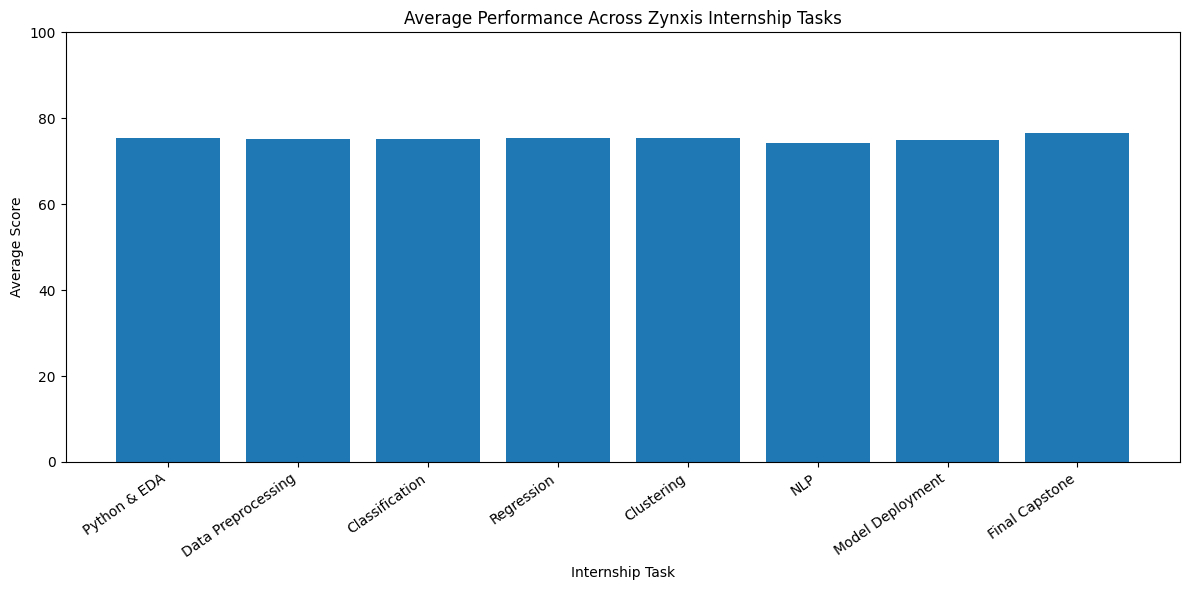

In [49]:
task_means = data[task_columns].mean()

task_names = [
    "Python & EDA",
    "Data Preprocessing",
    "Classification",
    "Regression",
    "Clustering",
    "NLP",
    "Model Deployment",
    "Final Capstone"
]

plt.figure(figsize=(12, 6))

plt.bar(task_names, task_means)

plt.title("Average Performance Across Zynxis Internship Tasks")
plt.xlabel("Internship Task")
plt.ylabel("Average Score")

plt.xticks(rotation=35, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

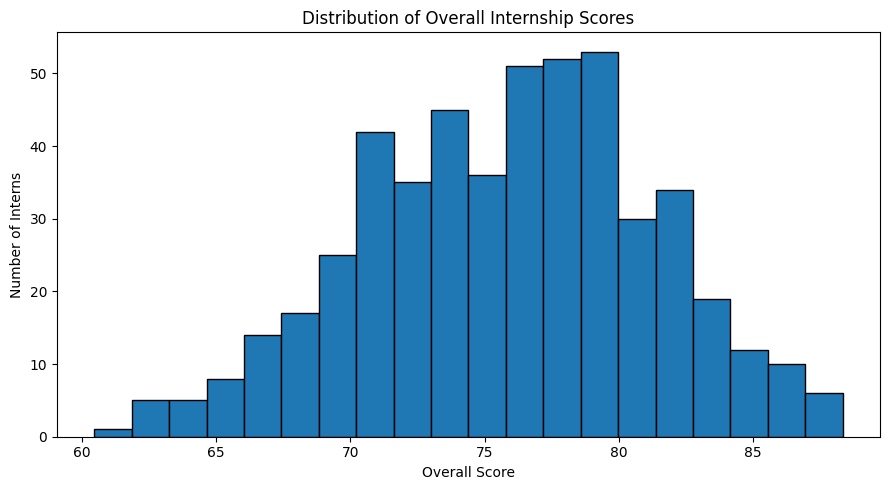

In [50]:
plt.figure(figsize=(9, 5))

plt.hist(data["Overall_Score"], bins=20, edgecolor="black")

plt.title("Distribution of Overall Internship Scores")
plt.xlabel("Overall Score")
plt.ylabel("Number of Interns")

plt.tight_layout()
plt.show()

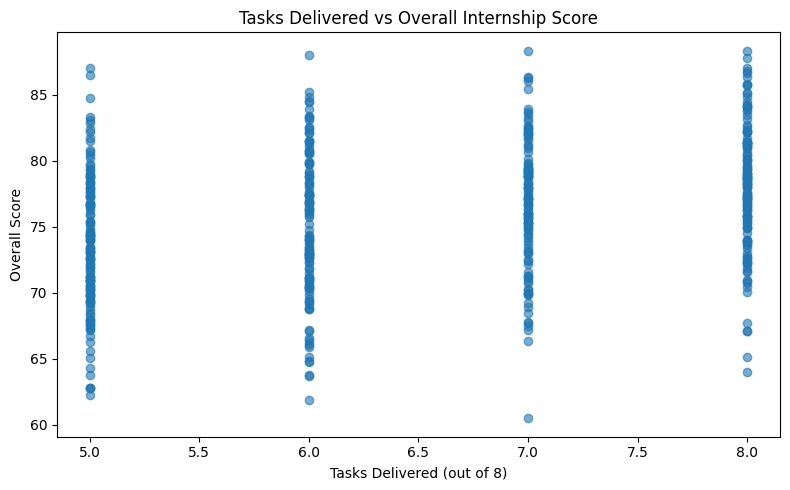

In [51]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["Tasks_Delivered"],
    data["Overall_Score"],
    alpha=0.6
)

plt.title("Tasks Delivered vs Overall Internship Score")
plt.xlabel("Tasks Delivered (out of 8)")
plt.ylabel("Overall Score")

plt.tight_layout()
plt.show()

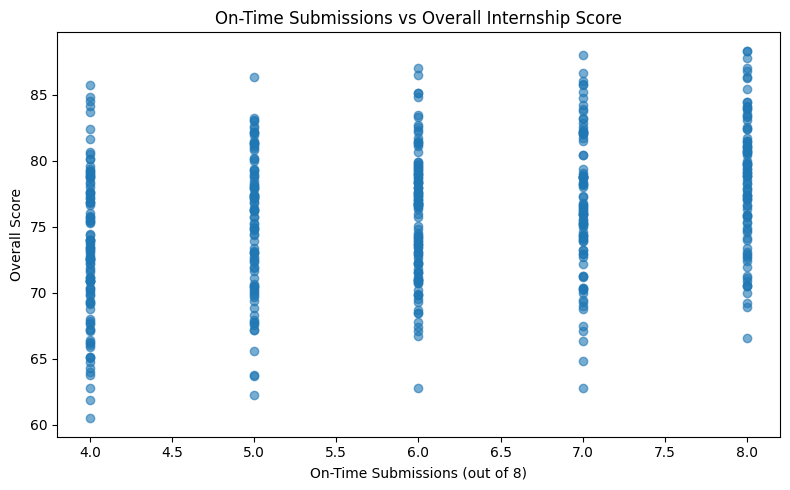

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["OnTime_Submissions"],
    data["Overall_Score"],
    alpha=0.6
)

plt.title("On-Time Submissions vs Overall Internship Score")
plt.xlabel("On-Time Submissions (out of 8)")
plt.ylabel("Overall Score")

plt.tight_layout()
plt.show()

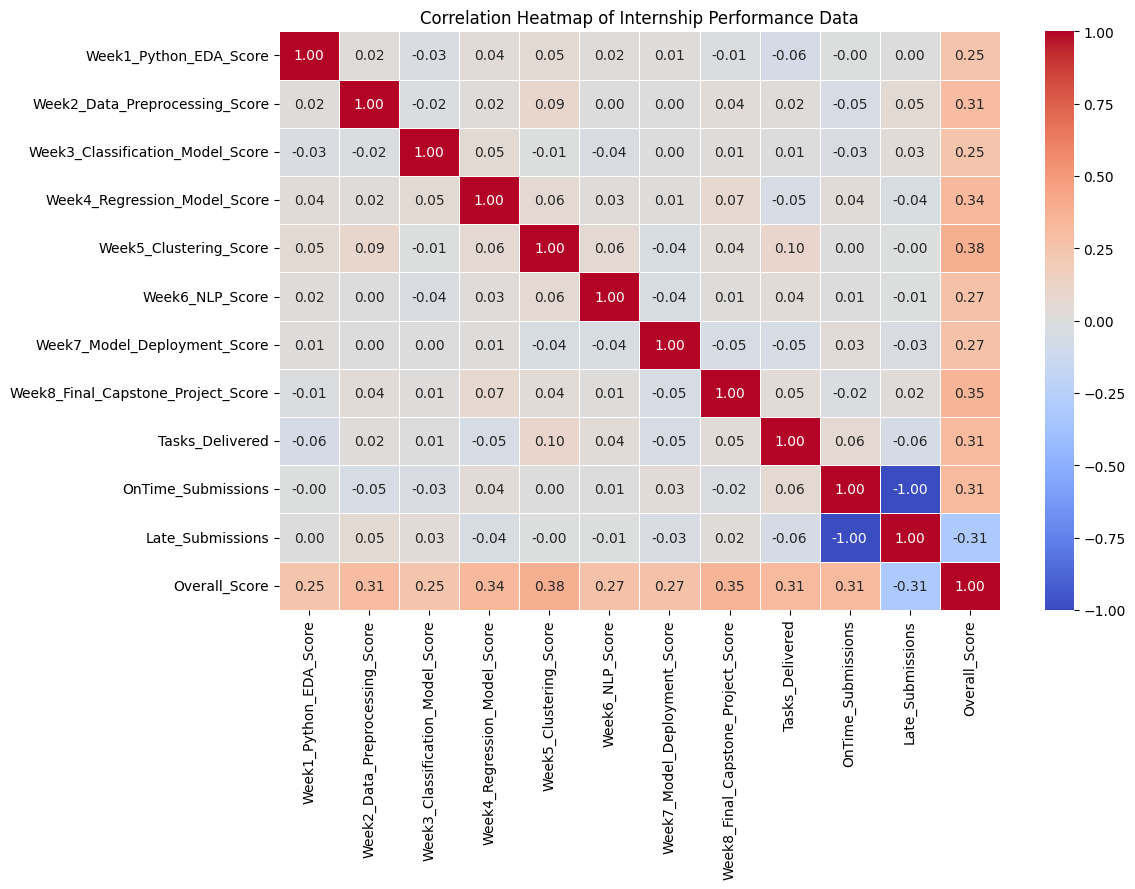

In [53]:
import seaborn as sns

plt.figure(figsize=(12, 9))

correlation = data.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Internship Performance Data")
plt.tight_layout()
plt.show()

# EDA Key Findings


* The average performance across the 8 internship tasks is around 75.
* Week 8 (Final Capstone Project) has the highest average score.
* NLP has the lowest average score among the 8 tasks.
* The average number of tasks delivered is about 6.5 out of 8.
* On-time submissions show a positive relationship with overall performance.
* Overall internship scores are mainly concentrated around the 70–80 range.
* The dataset contains 500 records with no missing values or duplicate rows.

# Step 3: Feature Selection

In [54]:
# Features
features = [
    "Week1_Python_EDA_Score",
    "Week2_Data_Preprocessing_Score",
    "Week3_Classification_Model_Score",
    "Week4_Regression_Model_Score",
    "Week5_Clustering_Score",
    "Week6_NLP_Score",
    "Week7_Model_Deployment_Score",
    "Week8_Final_Capstone_Project_Score",
    "Tasks_Delivered",
    "OnTime_Submissions",
    "Late_Submissions"
]

# Input features
X = data[features]

# Target variable
y = data["Overall_Score"]

print("Features:", features)
print("Target:", "Overall_Score")

Features: ['Week1_Python_EDA_Score', 'Week2_Data_Preprocessing_Score', 'Week3_Classification_Model_Score', 'Week4_Regression_Model_Score', 'Week5_Clustering_Score', 'Week6_NLP_Score', 'Week7_Model_Deployment_Score', 'Week8_Final_Capstone_Project_Score', 'Tasks_Delivered', 'OnTime_Submissions', 'Late_Submissions']
Target: Overall_Score


# Step 4: Train/Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 11)
Testing data: (100, 11)


#  Step 5: Train the Regression Models

In [56]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Create models
linear_model = LinearRegression()

ridge_model = Ridge(alpha=1.0)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


# Step 6: Evaluate the Models

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
linear_predictions = linear_model.predict(X_test)
ridge_predictions = ridge_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

# Calculate metrics
results = []

models = [
    ("Linear Regression", linear_predictions),
    ("Ridge Regression", ridge_predictions),
    ("Random Forest", random_forest_predictions)
]

for model_name, predictions in models:
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,MAE,MSE,R2 Score
0,Linear Regression,1.6014,4.0229,0.8400
1,Ridge Regression,1.6019,4.0239,0.8400
2,Random Forest,2.2201,7.4160,0.7051


# Step 7: Save the Best Model

In [58]:
# Select the model with the highest R2 Score
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(), "Model"
]

# Select the corresponding trained model
if best_model_name == "Linear Regression":
    best_model = linear_model

elif best_model_name == "Ridge Regression":
    best_model = ridge_model

else:
    best_model = random_forest_model

print("Best Model:", best_model_name)

best_row = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print(f"MAE: {best_row['MAE']:.4f}")
print(f"MSE: {best_row['MSE']:.4f}")
print(f"R2 Score: {best_row['R2 Score']:.4f}")

Best Model: Linear Regression
MAE: 1.6014
MSE: 4.0229
R2 Score: 0.8400


In [59]:
import joblib

joblib.dump(best_model, "zynxis_performance_model.pkl")
joblib.dump(features, "model_features.pkl")

print("Best model saved successfully!")
print("Feature list saved successfully!")

Best model saved successfully!
Feature list saved successfully!


# Step 8: Actual vs Predicted Graph

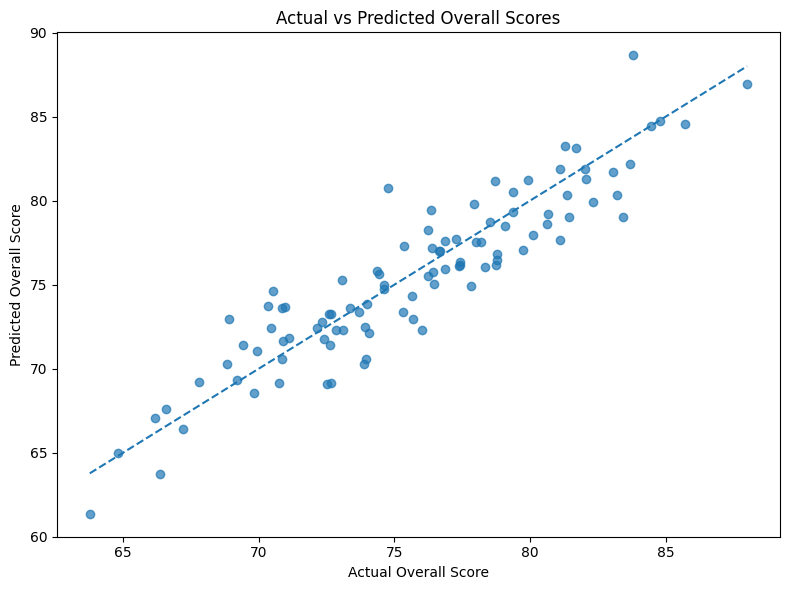

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_predictions, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Overall Scores")
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")

plt.tight_layout()
plt.show()

# Step 9: Individual Performace Predictor

In [61]:
# Select one intern from the test data
sample_intern = X_test.iloc[[0]]

# Get actual score
actual_score = y_test.iloc[0]

# Predict overall score
predicted_score = best_model.predict(sample_intern)[0]

print("Actual Overall Score:", round(actual_score, 2))
print("Predicted Overall Score:", round(predicted_score, 2))
print("Prediction Error:", round(abs(actual_score - predicted_score), 2))

Actual Overall Score: 76.0
Predicted Overall Score: 72.28
Prediction Error: 3.72


# Step 10: Performance Level and Personalized Suggestions

In [62]:
def get_performance_level(score):
    if score >= 85:
        return "Excellent"
    elif score >= 75:
        return "Good"
    elif score >= 65:
        return "Average"
    else:
        return "Needs Improvement"


def generate_suggestions(intern_data):
    suggestions = []

    # Check task scores
    task_scores = {
        "Python & EDA": intern_data["Week1_Python_EDA_Score"],
        "Data Preprocessing": intern_data["Week2_Data_Preprocessing_Score"],
        "Classification": intern_data["Week3_Classification_Model_Score"],
        "Regression": intern_data["Week4_Regression_Model_Score"],
        "Clustering": intern_data["Week5_Clustering_Score"],
        "NLP": intern_data["Week6_NLP_Score"],
        "Model Deployment": intern_data["Week7_Model_Deployment_Score"],
        "Final Capstone": intern_data["Week8_Final_Capstone_Project_Score"]
    }

    # Find weak tasks
    weak_tasks = [
        task for task, score in task_scores.items()
        if score < 70
    ]

    if weak_tasks:
        suggestions.append(
            "Focus on improving: " + ", ".join(weak_tasks)
        )

    # Submission advice
    if intern_data["OnTime_Submissions"] < 6:
        suggestions.append(
            "Try to submit more tasks on time."
        )

    # Task completion advice
    if intern_data["Tasks_Delivered"] < 8:
        suggestions.append(
            "Complete all 8 internship tasks."
        )

    # If no major weakness
    if not suggestions:
        suggestions.append(
            "Great performance! Keep maintaining your current level."
        )

    return suggestions


# Test with our sample intern
sample_data = sample_intern.iloc[0]

performance_level = get_performance_level(predicted_score)

suggestions = generate_suggestions(sample_data)

print("Predicted Score:", round(predicted_score, 2))
print("Performance Level:", performance_level)

print("\nPersonalized Suggestions:")
for suggestion in suggestions:
    print("-", suggestion)

Predicted Score: 72.28
Performance Level: Average

Personalized Suggestions:
- Focus on improving: NLP, Model Deployment, Final Capstone
- Try to submit more tasks on time.
- Complete all 8 internship tasks.


# Step 11: 8-Task Performance Chart

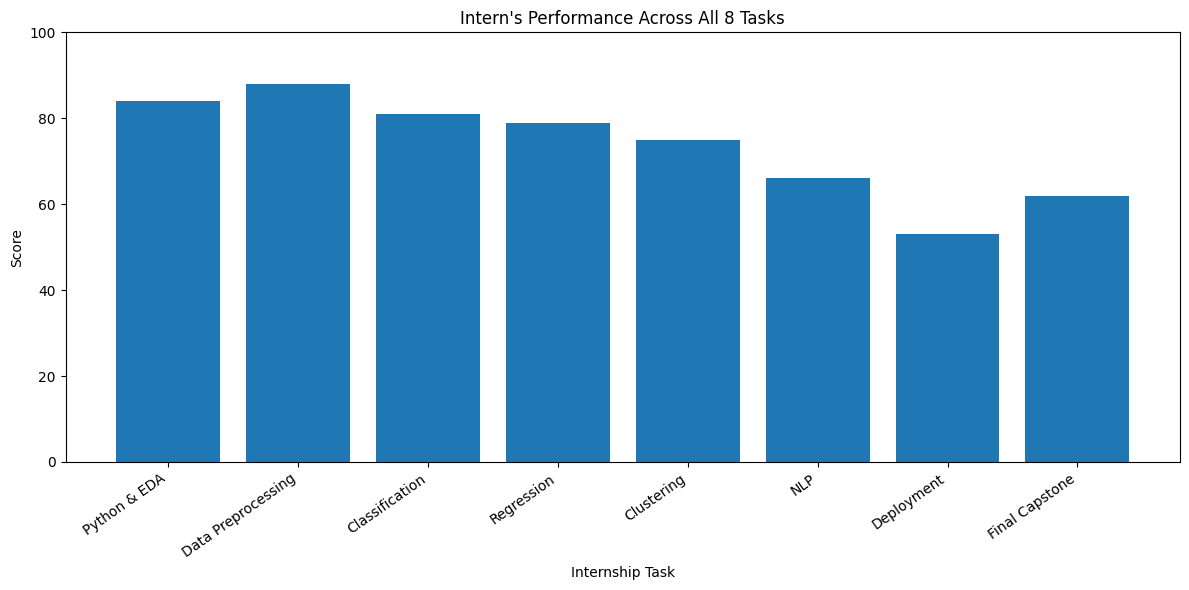

In [63]:
# Get sample intern's 8 task scores
sample_task_scores = [
    sample_data["Week1_Python_EDA_Score"],
    sample_data["Week2_Data_Preprocessing_Score"],
    sample_data["Week3_Classification_Model_Score"],
    sample_data["Week4_Regression_Model_Score"],
    sample_data["Week5_Clustering_Score"],
    sample_data["Week6_NLP_Score"],
    sample_data["Week7_Model_Deployment_Score"],
    sample_data["Week8_Final_Capstone_Project_Score"]
]

task_names = [
    "Python & EDA",
    "Data Preprocessing",
    "Classification",
    "Regression",
    "Clustering",
    "NLP",
    "Deployment",
    "Final Capstone"
]

plt.figure(figsize=(12, 6))

plt.bar(task_names, sample_task_scores)

plt.title("Intern's Performance Across All 8 Tasks")
plt.xlabel("Internship Task")
plt.ylabel("Score")

plt.ylim(0, 100)
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

# Step 12: Dashboard Metrics

In [64]:
# Calculate dashboard metrics

average_task_score = np.mean(sample_task_scores)

tasks_delivered = int(sample_data["Tasks_Delivered"])

on_time_submissions = int(sample_data["OnTime_Submissions"])

late_submissions = int(sample_data["Late_Submissions"])

on_time_rate = (on_time_submissions / 8) * 100

deliverable_status = f"{tasks_delivered}/8"

print("Average Task Score:", round(average_task_score, 2))
print("Tasks Delivered:", deliverable_status)
print("On-Time Submissions:", on_time_submissions)
print("Late Submissions:", late_submissions)
print("On-Time Submission Rate:", round(on_time_rate, 2), "%")
print("Predicted Overall Score:", round(predicted_score, 2))
print("Performance Level:", performance_level)

Average Task Score: 73.5
Tasks Delivered: 7/8
On-Time Submissions: 4
Late Submissions: 4
On-Time Submission Rate: 50.0 %
Predicted Overall Score: 72.28
Performance Level: Average


#  Step 13: Install Streamlit

In [65]:
!pip install -q streamlit

In [66]:
import streamlit
print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.61.1


# Step 14: App.py

In [67]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Zynxis Internship Performance Predictor",
    page_icon="🎓",
    layout="wide"
)

# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------

model = joblib.load("zynxis_performance_model.pkl")

# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.title("🎓 Zynxis AI / ML Internship Performance Predictor")

st.markdown(
    """
    ### AI-Based Internship Performance Analysis

    Enter your performance information for all **8 internship tasks**.
    The trained machine learning model will predict your overall score
    and provide personalized performance suggestions.
    """
)

st.divider()

# --------------------------------------------------
# TASK SCORES
# --------------------------------------------------

st.subheader("📊 Internship Task Scores")

col1, col2 = st.columns(2)

with col1:
    week1 = st.slider("Week 1 — Python & EDA", 0, 100, 75)
    week2 = st.slider("Week 2 — Data Preprocessing", 0, 100, 75)
    week3 = st.slider("Week 3 — Classification Model", 0, 100, 75)
    week4 = st.slider("Week 4 — Regression Model", 0, 100, 75)

with col2:
    week5 = st.slider("Week 5 — Clustering", 0, 100, 75)
    week6 = st.slider("Week 6 — NLP", 0, 100, 75)
    week7 = st.slider("Week 7 — Model Deployment", 0, 100, 75)
    week8 = st.slider("Week 8 — Final Capstone Project", 0, 100, 75)

st.divider()

# --------------------------------------------------
# SUBMISSION INFORMATION
# --------------------------------------------------

st.subheader("📋 Submission Information")

col1, col2, col3 = st.columns(3)

with col1:
    tasks_delivered = st.number_input(
        "Tasks Delivered",
        min_value=0,
        max_value=8,
        value=8
    )

with col2:
    on_time = st.number_input(
        "On-Time Submissions",
        min_value=0,
        max_value=8,
        value=8
    )

with col3:
    late = st.number_input(
        "Late Submissions",
        min_value=0,
        max_value=8,
        value=0
    )

st.divider()

# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

if st.button("🚀 Predict My Performance", use_container_width=True):

    # Feature data
    input_data = pd.DataFrame([{
        "Week1_Python_EDA_Score": week1,
        "Week2_Data_Preprocessing_Score": week2,
        "Week3_Classification_Model_Score": week3,
        "Week4_Regression_Model_Score": week4,
        "Week5_Clustering_Score": week5,
        "Week6_NLP_Score": week6,
        "Week7_Model_Deployment_Score": week7,
        "Week8_Final_Capstone_Project_Score": week8,
        "Tasks_Delivered": tasks_delivered,
        "OnTime_Submissions": on_time,
        "Late_Submissions": late
    }])

    # Prediction
    predicted_score = model.predict(input_data)[0]

    predicted_score = max(0, min(100, predicted_score))

    # Average score
    task_scores = [
        week1, week2, week3, week4,
        week5, week6, week7, week8
    ]

    average_score = np.mean(task_scores)

    # On-time rate
    on_time_rate = (on_time / 8) * 100

    # Performance level
    if predicted_score >= 85:
        performance = "Excellent 🟢"
    elif predicted_score >= 75:
        performance = "Good 🔵"
    elif predicted_score >= 65:
        performance = "Average 🟡"
    else:
        performance = "Needs Improvement 🔴"

    # --------------------------------------------------
    # DASHBOARD METRICS
    # --------------------------------------------------

    st.subheader("🎯 Performance Results")

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            "Average Task Score",
            f"{average_score:.1f}"
        )

    with col2:
        st.metric(
            "Tasks Delivered",
            f"{tasks_delivered}/8"
        )

    with col3:
        st.metric(
            "On-Time Rate",
            f"{on_time_rate:.1f}%"
        )

    with col4:
        st.metric(
            "Predicted Score",
            f"{predicted_score:.2f}"
        )

    st.success(
        f"### Performance Level: {performance}"
    )

    # --------------------------------------------------
    # 8-TASK CHART
    # --------------------------------------------------

    st.subheader("📈 8-Task Performance")

    chart_data = pd.DataFrame({
        "Task": [
            "Python & EDA",
            "Preprocessing",
            "Classification",
            "Regression",
            "Clustering",
            "NLP",
            "Deployment",
            "Capstone"
        ],
        "Score": task_scores
    })

    st.bar_chart(
        chart_data.set_index("Task")
    )

    # --------------------------------------------------
    # DELIVERABLE STATUS
    # --------------------------------------------------

    st.subheader("📦 Deliverable Completion")

    if tasks_delivered == 8:
        st.success("✅ All 8 internship tasks have been delivered!")
    else:
        st.warning(
            f"⚠️ {tasks_delivered}/8 tasks delivered. "
            "Complete the remaining tasks."
        )

    # --------------------------------------------------
    # PERSONALIZED SUGGESTIONS
    # --------------------------------------------------

    st.subheader("💡 Personalized Suggestions")

    suggestions = []

    task_dictionary = {
        "Python & EDA": week1,
        "Data Preprocessing": week2,
        "Classification": week3,
        "Regression": week4,
        "Clustering": week5,
        "NLP": week6,
        "Model Deployment": week7,
        "Final Capstone": week8
    }

    weak_tasks = [
        task for task, score in task_dictionary.items()
        if score < 70
    ]

    if weak_tasks:
        suggestions.append(
            "Focus on improving: " +
            ", ".join(weak_tasks)
        )

    if on_time < 6:
        suggestions.append(
            "Try to improve your on-time submission rate."
        )

    if tasks_delivered < 8:
        suggestions.append(
            "Complete all 8 internship tasks."
        )

    if not suggestions:
        suggestions.append(
            "Excellent work! Keep maintaining your performance."
        )

    for suggestion in suggestions:
        st.write("•", suggestion)

    # --------------------------------------------------
    # MODEL INFORMATION
    # --------------------------------------------------

    st.subheader("🤖 ML Model Information")

    st.info(
        """
        **Model:** Linear Regression

        **MAE:** 1.6014

        **MSE:** 4.0229

        **R² Score:** 0.8400

        The model was trained using internship task scores,
        task completion information, and submission behavior.
        """
    )

    # --------------------------------------------------
    # DOWNLOADABLE REPORT
    # --------------------------------------------------

    report = f"""
ZYNXIS INTERNSHIP PERFORMANCE REPORT
====================================

Average Task Score: {average_score:.2f}
Tasks Delivered: {tasks_delivered}/8
On-Time Submission Rate: {on_time_rate:.2f}%
Predicted Overall Score: {predicted_score:.2f}
Performance Level: {performance}

TASK SCORES
-----------
Python & EDA: {week1}
Data Preprocessing: {week2}
Classification: {week3}
Regression: {week4}
Clustering: {week5}
NLP: {week6}
Model Deployment: {week7}
Final Capstone: {week8}

MODEL
-----
Linear Regression
MAE: 1.6014
MSE: 4.0229
R2 Score: 0.8400
"""

    st.download_button(
        label="📥 Download Prediction Report",
        data=report,
        file_name="zynxis_performance_report.txt",
        mime="text/plain"
    )

Overwriting app.py


# Step 15: Launching

In [80]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("Model exists:", os.path.exists("zynxis_performance_model.pkl"))

app.py exists: True
Model exists: True


In [93]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > /content/log.txt 2>&1 &

In [94]:
!cat /content/log.txt



2026-08-16 12:59:22.093 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.106.44:8501



In [95]:
!cloudflared tunnel --url http://localhost:8501

2026-08-16T12:59:36Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-16T12:59:36Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-16T12:59:39Z INF +--------------------------------------------------------------------------------------------+
2026-08-16T12:59:39Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-16T12:59:39Z INF |  https://quote-rangers-explosion-nissan.trycloudflare.

In [96]:
!pkill -f streamlit
!pkill -f cloudflared

In [97]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > /content/log.txt 2>&1 &

In [98]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Sun, 16 Aug 2026 13:01:01 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10951
last-modified: Sun, 16 Aug 2026 12:44:28 GMT
etag: "672c1997c167d1ba91544478e0759b66"
cache-control: no-cache



In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-08-16T13:01:43Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-16T13:01:43Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-16T13:01:48Z INF +--------------------------------------------------------------------------------------------+
2026-08-16T13:01:48Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-16T13:01:48Z INF |  https://prayer-urban-barrier-calm.trycloudflare.com  